# Phase 4: Model Evaluation

In this phase, the trained SVM and Decision Tree models are loaded from disk and evaluated using multiple classification metrics and visualization techniques.

In [3]:
import pandas as pd
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

df = pd.read_csv("../data/processed/breast_cancer_processed.csv")

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

svm_model = joblib.load("../models/svm_model.pkl")

decision_tree = joblib.load("../models/decision_tree_model.pkl")

svm_predictions = svm_model.predict(X_test)

dt_predictions = decision_tree.predict(X_test)


In [4]:
print("SVM Performance")

print("Accuracy :", accuracy_score(y_test, svm_predictions))
print("Precision:", precision_score(y_test, svm_predictions))
print("Recall   :", recall_score(y_test, svm_predictions))
print("F1 Score :", f1_score(y_test, svm_predictions))

print("\nClassification Report\n")

print(classification_report(y_test, svm_predictions))

SVM Performance
Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1 Score : 0.9861111111111112

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



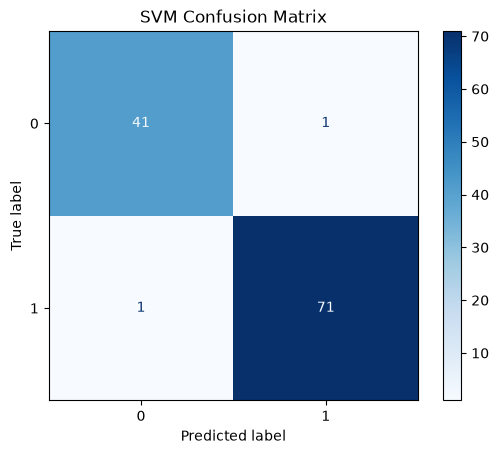

In [5]:
ConfusionMatrixDisplay.from_estimator(
    svm_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("SVM Confusion Matrix")

plt.show()

In [6]:
print("Decision Tree Performance")

print("Accuracy :", accuracy_score(y_test, dt_predictions))
print("Precision:", precision_score(y_test, dt_predictions))
print("Recall   :", recall_score(y_test, dt_predictions))
print("F1 Score :", f1_score(y_test, dt_predictions))

print("\nClassification Report\n")

print(classification_report(y_test, dt_predictions))

Decision Tree Performance
Accuracy : 0.9210526315789473
Precision: 0.9565217391304348
Recall   : 0.9166666666666666
F1 Score : 0.9361702127659575

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.93      0.90        42
           1       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



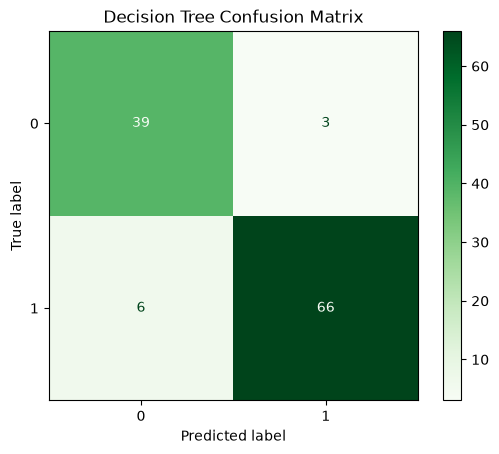

In [7]:
ConfusionMatrixDisplay.from_estimator(
    decision_tree,
    X_test,
    y_test,
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")

plt.show()

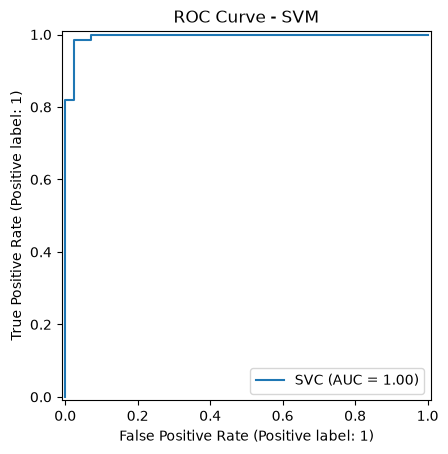

In [8]:
RocCurveDisplay.from_estimator(
    svm_model,
    X_test,
    y_test
)

plt.title("ROC Curve - SVM")

plt.show()

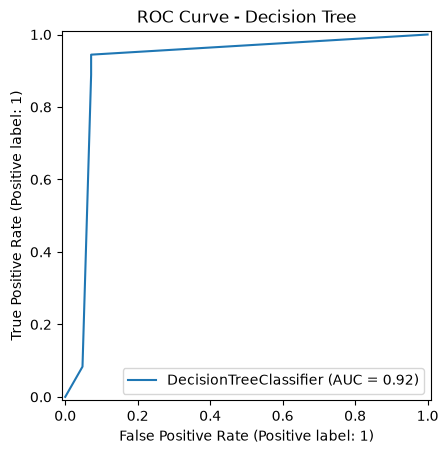

In [9]:
RocCurveDisplay.from_estimator(
    decision_tree,
    X_test,
    y_test
)

plt.title("ROC Curve - Decision Tree")

plt.show()

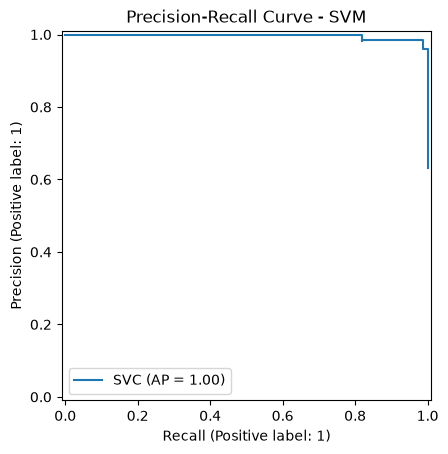

In [10]:
PrecisionRecallDisplay.from_estimator(
    svm_model,
    X_test,
    y_test
)

plt.title("Precision-Recall Curve - SVM")

plt.show()

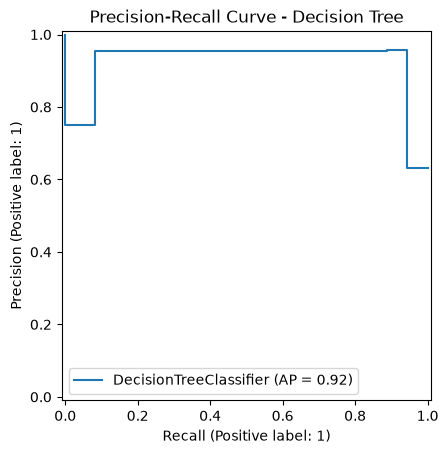

In [11]:
PrecisionRecallDisplay.from_estimator(
    decision_tree,
    X_test,
    y_test
)

plt.title("Precision-Recall Curve - Decision Tree")

plt.show()

In [12]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "SVM": [
        accuracy_score(y_test, svm_predictions),
        precision_score(y_test, svm_predictions),
        recall_score(y_test, svm_predictions),
        f1_score(y_test, svm_predictions)
    ],
    "Decision Tree": [
        accuracy_score(y_test, dt_predictions),
        precision_score(y_test, dt_predictions),
        recall_score(y_test, dt_predictions),
        f1_score(y_test, dt_predictions)
    ]
})

comparison

,Metric,SVM,Decision Tree
0,Accuracy,0.982456,0.921053
1,Precision,0.986111,0.956522
2,Recall,0.986111,0.916667
3,F1 Score,0.986111,0.936170


# Conclusion

The Support Vector Machine (SVM) achieved the highest performance across all evaluation metrics, with an accuracy of approximately 98%.

Although the Decision Tree classifier obtained slightly lower accuracy (approximately 92%), it offers better interpretability through its decision rules and feature importance visualization.

Overall, the SVM model is selected as the best-performing classifier for the Breast Cancer Wisconsin Diagnostic dataset due to its superior predictive performance.